In [13]:
import numpy as np
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch import nn
import math
import seaborn as sns

%matplotlib inline

torch.Size([10000, 2])


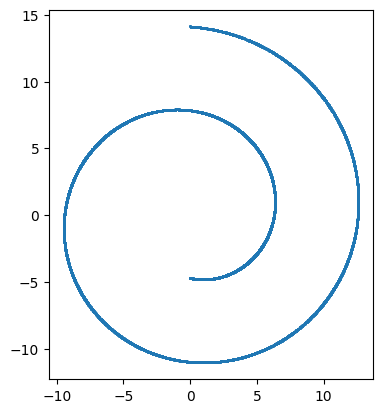

Data range: x=[-1.75, 1.60]
Data range: y=[-1.61, 2.02]


In [14]:
swiss_roll = make_swiss_roll(n_samples=10000, noise=0)[0][:, ::2]
train_set = torch.tensor(swiss_roll).float()

mu, std = train_set.mean(0), train_set.std(0)
train_set = (train_set - mu) / std
print(train_set.shape)
plt.axes().set_aspect('equal')
plt.scatter(swiss_roll[:, 0], swiss_roll[:, 1], s=1)
plt.show()

print(f"Data range: x=[{train_set[:,0].min():.2f}, {train_set[:,0].max():.2f}]")
print(f"Data range: y=[{train_set[:,1].min():.2f}, {train_set[:,1].max():.2f}]")

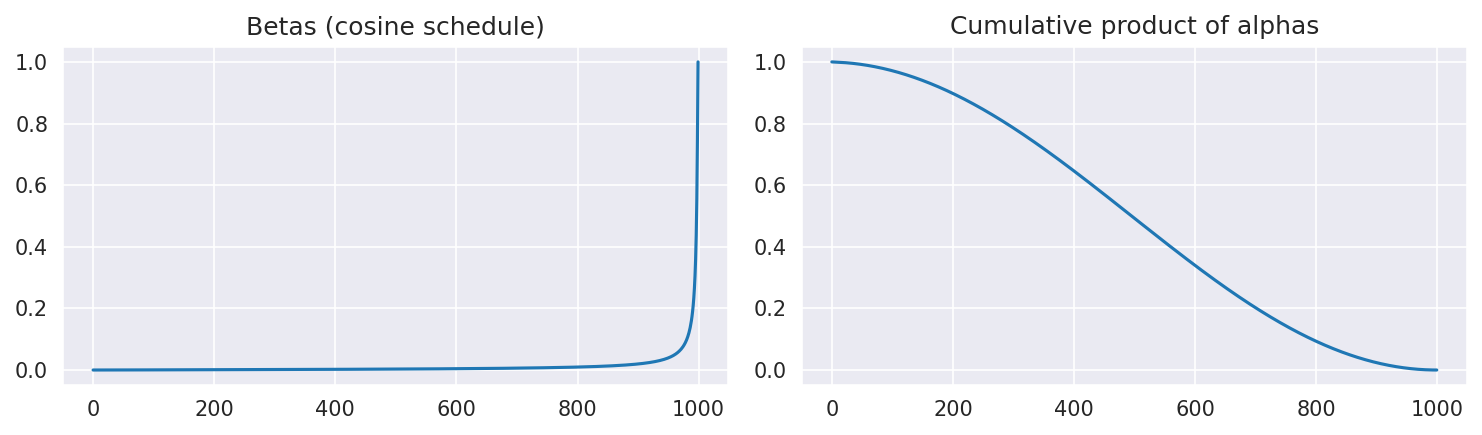

In [15]:
# DDPM noise schedule
# "Improved Denoising Diffusion Probabilistic Models" https://arxiv.org/abs/2102.09672

def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

T = 1000
betas = cosine_beta_schedule(T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

# Visualize schedule
with sns.axes_style("darkgrid"):
    fig, axs = plt.subplots(1, 2, figsize=(10, 3), dpi=150)
    axs[0].plot(betas.numpy())
    axs[0].set_title("Betas (cosine schedule)")
    axs[1].plot(alphas_cumprod.numpy())
    axs[1].set_title("Cumulative product of alphas")
    plt.tight_layout()
    plt.show()

In [16]:
def extract(a, t, x_shape):
    """Gather schedule values at timestep t and broadcast to x_shape."""
    out = a.gather(-1, t.cpu())
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1))).to(t.device)

def q_sample(x_start, t, noise=None):
    """Forward diffusion: add noise to x_start at timestep t."""
    if noise is None:
        noise = torch.randn_like(x_start)
    sqrt_ac_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_1m_ac_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)
    return sqrt_ac_t * x_start + sqrt_1m_ac_t * noise

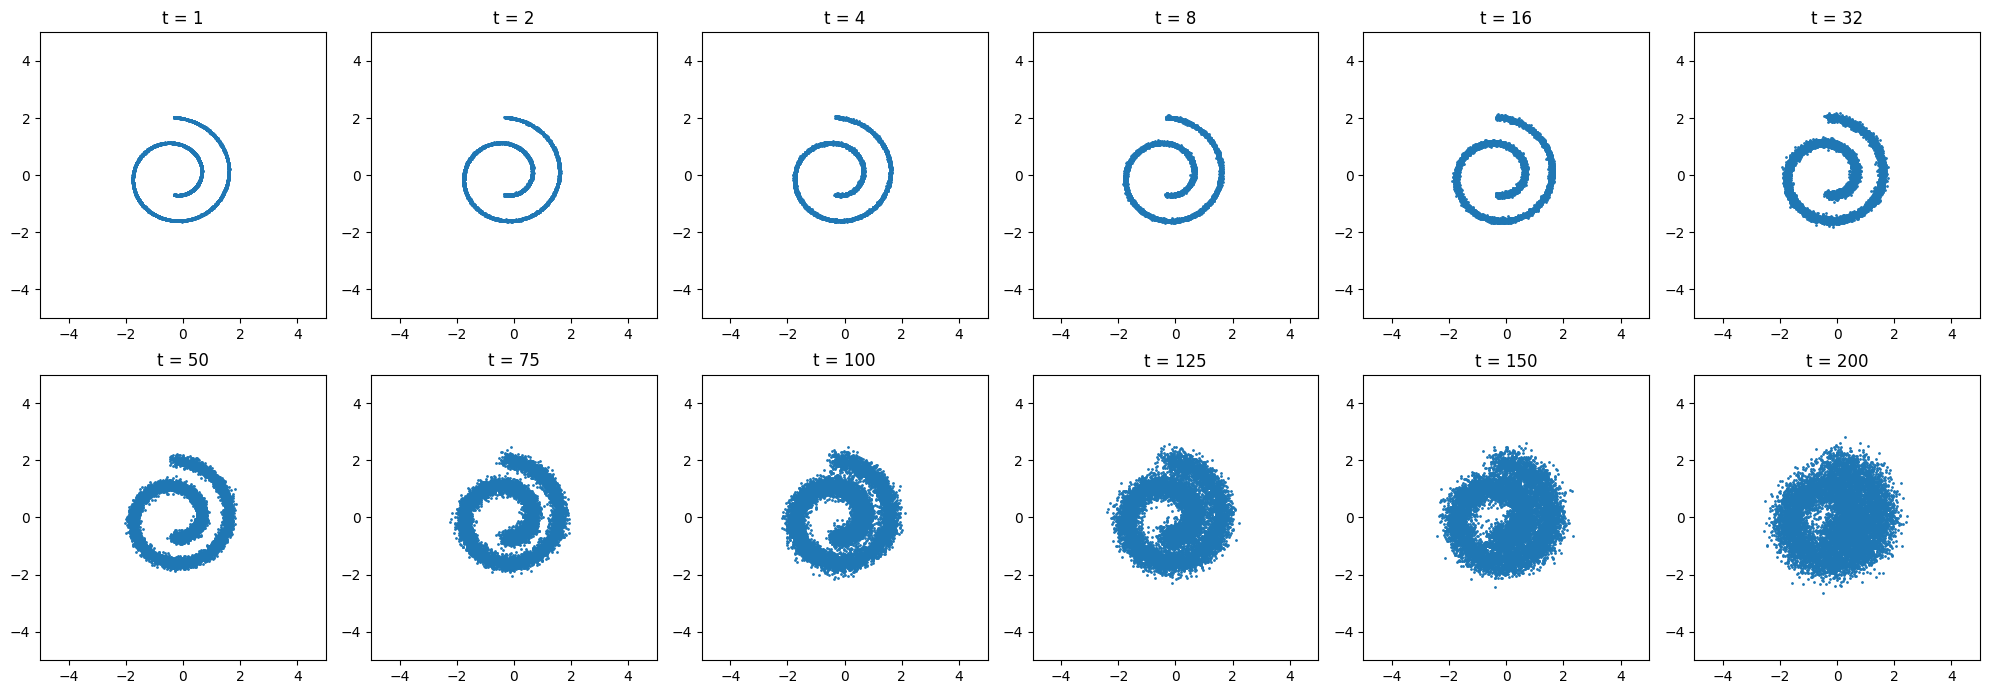

In [17]:
# Visualize how the swiss roll degrades as t increases
fig, axs = plt.subplots(2, 6, figsize=(20, 7))

for i, t_val in enumerate([1, 2, 4, 8, 16, 32, 50, 75, 100, 125, 150, 200]):
    noisy = q_sample(train_set, torch.tensor(len(train_set) * [t_val - 1])).numpy()
    axs[i // 6, i % 6].scatter(noisy[:, 0], noisy[:, 1], s=1)
    axs[i // 6, i % 6].set_xlim(-5, 5)
    axs[i // 6, i % 6].set_ylim(-5, 5)
    axs[i // 6, i % 6].set_aspect('equal')
    axs[i // 6, i % 6].set_title(f't = {t_val}')

plt.tight_layout()
plt.show()

In [22]:
# Same backbone as flow_matching (TinyMLP + Residual). The ONLY addition vs
# flow_matching is a sinusoidal time embedding: with T=1000 discrete noise
# levels and a cosine schedule, the loss magnitude varies a lot with t, so a
# single scalar t/T is not a strong enough conditioning signal. Sinusoidal
# embeddings are the standard DDPM trick and don't change the MLP body.

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: (B, 1) float in [0, 1]
        device = t.device
        half = self.dim // 2
        # frequencies on log scale, t scaled to be comparable to "position"
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=device) / half)
        args = t * 1000.0 * freqs  # (B, half)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)


class Residual(nn.Module):
    def __init__(self, num_in):
        super(Residual, self).__init__()
        self.lin = nn.Linear(num_in, num_in)
        self.norm = nn.LayerNorm(num_in)

    def forward(self, x):
        return F.gelu(self.norm(self.lin(x))) + x


class TinyMLP(nn.Module):
    """Tiny MLP conditioned on time t (float in [0, 1]) via sinusoidal embedding."""
    def __init__(self, num_in, hidden, time_dim=64):
        super(TinyMLP, self).__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.mlp = nn.Sequential(
            nn.Linear(num_in + time_dim, hidden),
            nn.GELU(),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            nn.GELU(),
            nn.Linear(hidden, num_in)
        )

    def forward(self, z, t):
        """z: (B, D), t: (B, 1) float in [0, 1]"""
        t_emb = self.time_embed(t)
        return self.mlp(torch.cat((z, t_emb), dim=1))


def train_step(x, net, optimizer):
    """DDPM training: predict the noise added at a random timestep."""
    t = torch.randint(0, T, (len(x),), device=x.device)
    noise = torch.randn_like(x)
    x_noisy = q_sample(x, t, noise=noise)
    # Normalize integer timestep to [0, 1] for the time embedding
    t_float = (t.float() / T).unsqueeze(1)
    noise_pred = net(x_noisy, t_float)
    loss = F.mse_loss(noise_pred, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

loss = 1.358505:   0%|                                                    | 0/10000 [00:00<?, ?it/s]

loss = 0.412052: 100%|████████████████████████████████████████| 10000/10000 [02:02<00:00, 81.57it/s]


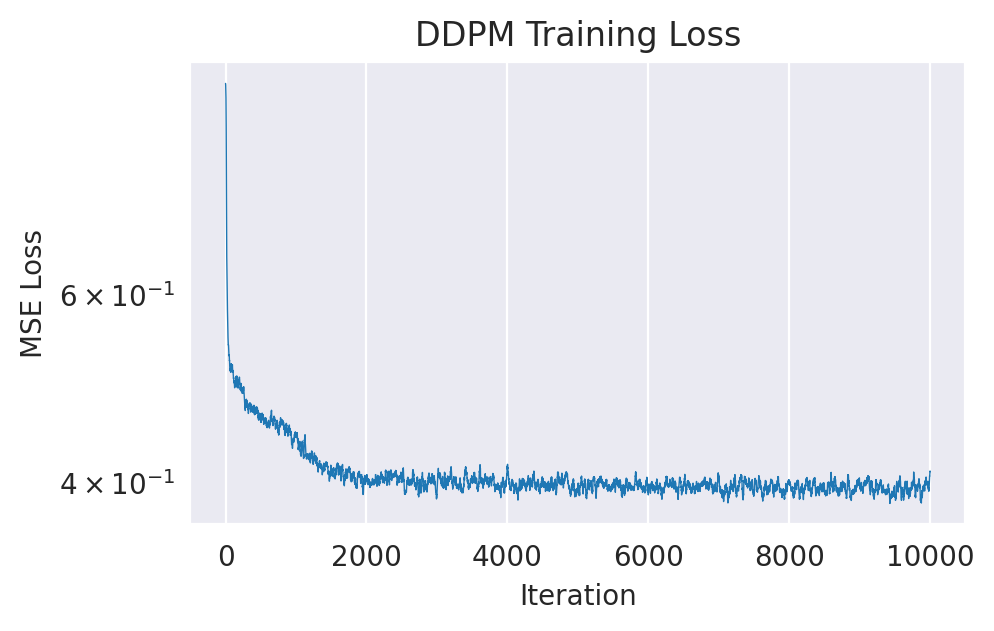

In [23]:
from numpy.lib.stride_tricks import sliding_window_view


def train(data, net, niter, lr):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    net.to(device)
    data = data.to(device)
    optim = torch.optim.AdamW(net.parameters(), lr=lr)
    batch_size = 1000
    losses = []
    for itr in (pbar := tqdm(range(niter), ncols=100)):
        idx = torch.randperm(len(data))[:batch_size]
        x = data[idx].contiguous()
        loss = train_step(x, net, optim)
        losses.append(loss.item())
        pbar.set_description(f"loss = {loss.item():06f}")
    return losses


# DDPM needs longer training than flow matching to learn the noise prediction
# at every one of T=1000 timesteps. Use the same 10000 iters as flow_matching,
# and a slightly wider hidden layer.
niter = 10000
lr = 1e-3
model = TinyMLP(2, 64)
model.train()
losses = train(train_set, model, niter, lr)
losses_smooth = sliding_window_view(np.pad(losses, (10, 10), mode='reflect'), 21).mean(axis=1)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(1, 1, figsize=(5, 3), dpi=200)
    ax.semilogy(np.arange(niter), losses_smooth, linewidth=0.5)
    ax.set_title('DDPM Training Loss')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE Loss')
    plt.show()

In [26]:
# Sampling clip range: data is standardized (mean 0, std 1) so almost all
# real samples lie in [-3, 3]. Clipping the x0 prediction inside the DDIM
# step prevents the well-known blowup at the largest timesteps where
# alphas_cumprod ~ 0 and dividing by sqrt(ac_t) amplifies tiny errors.
X0_CLIP = 3.0


@torch.no_grad()
def p_sample(model, x, t_int):
    """DDPM ancestral reverse step: denoise x from timestep t_int to t_int-1."""
    device = x.device
    t_batch = torch.full((len(x),), t_int, device=device, dtype=torch.long)
    t_float = (t_batch.float() / T).unsqueeze(1)

    ac_t = extract(alphas_cumprod, t_batch, x.shape).to(device)
    sqrt_1m_ac_t = extract(sqrt_one_minus_alphas_cumprod, t_batch, x.shape).to(device)

    noise_pred = model(x, t_float)
    # Predict x0 and clip for stability
    x0_pred = ((x - sqrt_1m_ac_t * noise_pred) / torch.sqrt(ac_t)).clamp(-X0_CLIP, X0_CLIP)

    if t_int == 0:
        return x0_pred

    # Posterior mean q(x_{t-1} | x_t, x0)
    t_prev_batch = torch.full((len(x),), t_int - 1, device=device, dtype=torch.long)
    ac_prev = extract(alphas_cumprod, t_prev_batch, x.shape).to(device)
    betas_t = extract(betas, t_batch, x.shape).to(device)

    coef_x0 = torch.sqrt(ac_prev) * betas_t / (1.0 - ac_t)
    coef_xt = torch.sqrt(1.0 - betas_t) * (1.0 - ac_prev) / (1.0 - ac_t)
    mean = coef_x0 * x0_pred + coef_xt * x

    pv_t = extract(posterior_variance, t_batch, x.shape).to(device)
    noise = torch.randn_like(x)
    return mean + torch.sqrt(pv_t) * noise


@torch.no_grad()
def ddim_step(model, x, t_int, t_prev_int):
    """DDIM deterministic step (η=0): goes from t_int → t_prev_int in one step.
    Allows sampling in ~50 steps instead of T=1000.
    """
    device = x.device
    t_batch = torch.full((len(x),), t_int, device=device, dtype=torch.long)
    t_float = (t_batch.float() / T).unsqueeze(1)

    ac_t = extract(alphas_cumprod, t_batch, x.shape).to(device)
    if t_prev_int >= 0:
        t_prev_batch = torch.full((len(x),), t_prev_int, device=device, dtype=torch.long)
        ac_prev = extract(alphas_cumprod, t_prev_batch, x.shape).to(device)
    else:
        ac_prev = torch.ones_like(ac_t)

    noise_pred = model(x, t_float)
    # Predict x0 from noise prediction (with clipping for stability)
    x0_pred = ((x - torch.sqrt(1 - ac_t) * noise_pred) / torch.sqrt(ac_t)).clamp(-X0_CLIP, X0_CLIP)
    # DDIM update (deterministic, η=0)
    x_prev = torch.sqrt(ac_prev) * x0_pred + torch.sqrt(1 - ac_prev) * noise_pred
    return x_prev


@torch.no_grad()
def generate_samples_ddpm(model, n_samples=1000):
    """Full DDPM ancestral sampling (T steps)."""
    device = next(model.parameters()).device
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    for t_int in tqdm(reversed(range(T)), total=T, desc='DDPM', ncols=80, leave=False):
        x = p_sample(model, x, t_int)
    return x.cpu()


@torch.no_grad()
def generate_samples(model, n_samples=1000, n_steps=200):
    """Fast DDIM sampling: n_steps << T gives nearly identical quality."""
    device = next(model.parameters()).device
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    timesteps = torch.linspace(T - 1, 0, n_steps + 1).long().tolist()
    for i in tqdm(range(len(timesteps) - 1), desc='DDIM', ncols=80, leave=False):
        x = ddim_step(model, x, timesteps[i], timesteps[i + 1])
    return x.cpu()


@torch.no_grad()
def generate_samples_collect(model, n_samples=1000, n_steps=50):
    """Collect intermediate states during DDIM denoising for animation."""
    device = next(model.parameters()).device
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    timesteps = torch.linspace(T - 1, 0, n_steps + 1).long().tolist()
    collected = [x.cpu().numpy()]
    for i in range(len(timesteps) - 1):
        x = ddim_step(model, x, timesteps[i], timesteps[i + 1])
        collected.append(x.cpu().numpy())
    return collected

FID: 0.0039


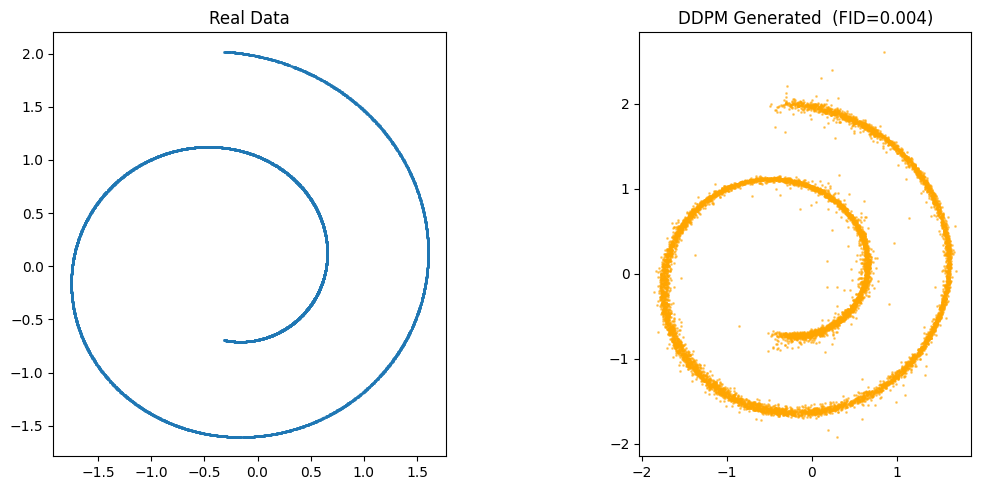

In [27]:
from scipy.linalg import sqrtm

samples = generate_samples(model, n_samples=10000, n_steps=200)


def fid_2d(real, fake):
    if isinstance(real, np.ndarray):
        assert isinstance(fake, np.ndarray)
        mu_r, mu_g = real.mean(0), fake.mean(0)
        sigma_r, sigma_g = np.cov(real, rowvar=False), np.cov(fake, rowvar=False)
        covmean = sqrtm(sigma_r @ sigma_g)
        fid = np.sum((mu_r - mu_g)**2) + np.trace(sigma_r + sigma_g - 2 * covmean)
        return np.real(fid)
    elif isinstance(real, torch.Tensor):
        mu_r, mu_g = real.mean(0), fake.mean(0)
        sigma_r = torch.cov(real.T)
        sigma_g = torch.cov(fake.T)
        cov_prod = sigma_r @ sigma_g
        eigvals, eigvecs = torch.linalg.eigh(cov_prod)
        sqrt_cov_prod = eigvecs @ torch.diag(torch.sqrt(torch.clamp(eigvals, min=0))) @ eigvecs.T
        fid = torch.sum((mu_r - mu_g)**2) + torch.trace(sigma_r + sigma_g - 2 * sqrt_cov_prod)
        return fid.item()


real_cpu = train_set.cpu()
fid = fid_2d(real_cpu, samples.float())
print(f"FID: {fid:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(real_cpu[:, 0].numpy(), real_cpu[:, 1].numpy(), s=1, alpha=0.5)
axs[0].set_title('Real Data')
axs[0].set_aspect('equal')
axs[1].scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), s=1, alpha=0.5, c='orange')
axs[1].set_title(f'DDPM Generated  (FID={fid:.3f})')
axs[1].set_aspect('equal')
plt.tight_layout()
plt.show()

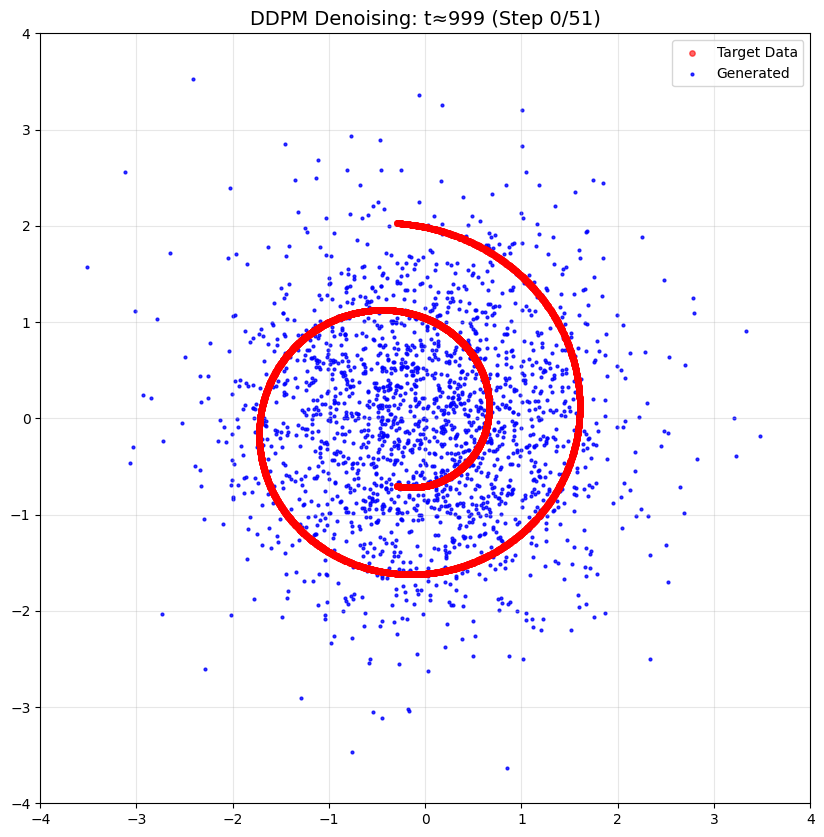

In [10]:
from matplotlib.animation import FuncAnimation


def animate_diffusion(model, n_samples=1000, n_steps=50, interval=100):
    collected = generate_samples_collect(model, n_samples, n_steps)
    total_frames = len(collected)

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    real_data = train_set.cpu().numpy()
    ax.scatter(real_data[:, 0], real_data[:, 1], c='red', alpha=0.6, s=15, label='Target Data', zorder=5)

    scat = ax.scatter([], [], c='blue', alpha=0.8, s=4, label='Generated')
    title = ax.set_title('DDPM Denoising', fontsize=14)
    ax.legend()

    def animate(frame):
        # timesteps go from T-1 → 0 across frames
        t_approx = int((T - 1) * (1 - frame / total_frames))
        scat.set_offsets(collected[frame])
        title.set_text(f'DDPM Denoising: t≈{t_approx} (Step {frame}/{total_frames})')
        return scat, title

    anim = FuncAnimation(fig, animate, frames=total_frames, interval=interval, blit=False, repeat=True)
    return anim


anim = animate_diffusion(model, n_samples=2000, n_steps=50, interval=150)

from IPython.display import HTML
HTML(anim.to_jshtml())